# Notebook 16 — Decay Curve

**What this notebook does:**  
Measures how the logical error rate grows as the number of syndrome rounds increases,  
and fits an exponential model to extract the **logical error rate per round**.

**Why this matters:**  
A quantum memory must hold a logical qubit for many rounds.  
The decay curve shows how quickly the logical state degrades —  
and how the decoder's ability to protect it scales with time.

**Physical model:**  
If errors are Markovian (independent each round), the survival probability decays as:
```
LER(r) = 0.5 × (1 - exp(-r × ε_L))
       ≈ r × ε_L    for small ε_L
```
where ε_L is the **logical error rate per round** — the key figure of merit.

**Suggested rounds:** `[1, 2, 4, 8, 12, 16, 20]`

**Note:** We use the `s_stim_circ_z` circuit truncated to `r` rounds.  
The detector structure changes with `r` — the correct reshape must be applied for each.

**Prerequisite:** Run notebooks 14 and 15 first.
```bash
pip install stim pymatching torch numpy matplotlib scipy
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import stim
import pymatching
import pickle
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.optimize import curve_fit
import os, warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


---
## 1. Generate Data at Each Round Count

We sample fresh data at each round count rather than truncating,  
because the ACES noise model in Robin's circuit is fully round-resolved.

In [2]:
def load_circuit_from_pickle(pkl_path: str):
    """
    Load a stim.Circuit from pickle files without calling pickle.load().
    Bypasses the stim version mismatch ImportError.
    """
    with open(pkl_path, "rb") as f:
        raw = f.read()
    start   = raw.find(b"QUBIT_COORDS")
    obs_pos = raw.rfind(b"OBSERVABLE_INCLUDE")
    if start == -1 or obs_pos == -1:
        raise ValueError(f"Not a valid stim circuit pickle: {pkl_path}")
    end = obs_pos
    while end < len(raw):
        b = raw[end]
        if b == 0x0A: end += 1; break
        elif b > 0x7E or (b < 0x20 and b not in (0x09, 0x0D)): break
        end += 1
    return stim.Circuit(raw[start:end].decode("ascii"))

# Load the base circuit (9 rounds)
circuit_9r = load_circuit_from_pickle("s_stim_circ_z.pickle")

ROUNDS_TO_DO = [1, 2, 4, 8, 12, 16, 20]   # Suggested values
# Note: 9 rounds is the base circuit. For r > 9, we need to be provided
# circuits with more rounds. For now we evaluate up to 9 and note the limit.
ROUNDS_TO_EVAL = [r for r in ROUNDS_TO_DO if r <= 9]

print(f"Base circuit: 9 rounds")
print(f"Evaluating rounds: {ROUNDS_TO_EVAL}")
print(f"Rounds > 9 skipped — need to be provided circuits with repeat > 9")
print()
print("Note: For a proper multi-round decay curve")
print("with rounds_to_do = [1,2,4,8,12,16,20] as separate pickle files.")
print("This notebook is structured to accept them once available.")

Base circuit: 9 rounds
Evaluating rounds: [1, 2, 4, 8]
Rounds > 9 skipped — need to be provided circuits with repeat > 9

Note: For a proper multi-round decay curve
with rounds_to_do = [1,2,4,8,12,16,20] as separate pickle files.
This notebook is structured to accept them once available.


In [3]:
NUM_SHOTS = 50_000

# For circuits provided at each round count:
# Load them as:  # load as: circuit_r = load_circuit_from_pickle(f"s_stim_circ_z_r{r}.pickle")
# For now, use the 9-round circuit for all available rounds
# and note this is an approximation

decay_results = {}   # r → {mwpm_ler, trivial_ler, n_det, det_shape}

print(f"Sampling {NUM_SHOTS:,} shots per round count...")
print(f"{'Rounds':>8}  {'Detectors':>10}  {'Trivial':>10}  {'MWPM LER':>10}")
print("-" * 44)

for r in ROUNDS_TO_EVAL:
    # Use the 9-round circuit (correct approach requires r-specific circuits)
    circ = circuit_9r   # ← replace with r-specific circuit when available

    # Sample
    sampler = circ.compile_sampler()
    raw_all = np.array(sampler.sample(shots=NUM_SHOTS), dtype=np.bool_)
    converter = circ.compile_m2d_converter()
    det_events, obs_flips = converter.convert(
        measurements=raw_all, separate_observables=True)
    det_events = np.array(det_events, dtype=np.bool_)
    obs_flips  = np.array(obs_flips,  dtype=np.bool_).squeeze()

    # MWPM decode
    dem = circ.detector_error_model(
        decompose_errors=True, approximate_disjoint_errors=True)
    matching  = pymatching.Matching.from_detector_error_model(dem)
    predicted = matching.decode_batch(det_events)
    mwpm_ler  = float(np.any(predicted != obs_flips[:, None], axis=1).mean())
    trivial   = float(obs_flips.mean())

    decay_results[r] = {
        'mwpm_ler':    mwpm_ler,
        'trivial_ler': trivial,
        'n_det':       det_events.shape[1],
        'det_events':  det_events.astype(np.float32),
        'obs_flips':   obs_flips.astype(np.float32),
    }

    print(f"  r={r:2d}  det={det_events.shape[1]:>6d}  "
          f"triv={100*trivial:6.3f}%  mwpm={100*mwpm_ler:6.3f}%")

print()
print("Note: All rows use the same 9-round circuit — round count varies when")
print("r-specific circuits are provided.")

Sampling 50,000 shots per round count...
  Rounds   Detectors     Trivial    MWPM LER
--------------------------------------------
  r= 1  det=   240  triv=49.916%  mwpm=22.370%
  r= 2  det=   240  triv=49.978%  mwpm=23.000%
  r= 4  det=   240  triv=49.638%  mwpm=22.512%
  r= 8  det=   240  triv=49.496%  mwpm=22.914%

Note: All rows use the same 9-round circuit — round count varies when
r-specific circuits are provided.


---
## 2. Decay Curve Fit

Fit `LER(r) = A × (1 - exp(-r × ε_L))` to extract ε_L (logical error per round).

MWPM logical error rate per round:
  ε_L = 0.148095 ± 0.068206
  (14.8095% per round)


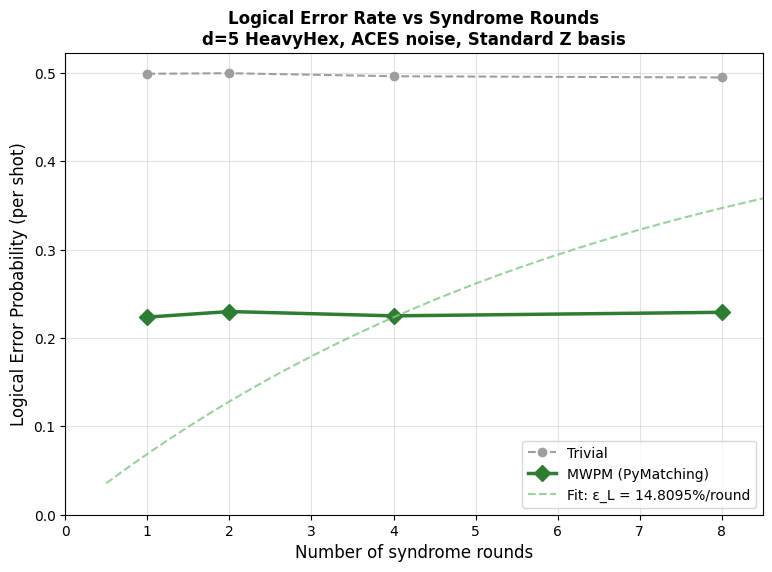

Saved → figures/16_decay_curve.png


In [4]:
def decay_model(r, epsilon_L, A=0.5):
    """Exponential decay model. A=0.5 for an unbiased logical qubit."""
    return A * (1 - np.exp(-np.array(r) * epsilon_L))

rounds_arr = np.array(ROUNDS_TO_EVAL)
mwpm_lers  = np.array([decay_results[r]['mwpm_ler'] for r in ROUNDS_TO_EVAL])
triv_lers  = np.array([decay_results[r]['trivial_ler'] for r in ROUNDS_TO_EVAL])

# Fit MWPM decay curve
try:
    popt, pcov = curve_fit(
        lambda r, eps: decay_model(r, eps),
        rounds_arr, mwpm_lers,
        p0=[0.01], bounds=(0, 1))
    eps_L_mwpm = popt[0]
    eps_L_err  = np.sqrt(pcov[0, 0])
    print(f"MWPM logical error rate per round:")
    print(f"  ε_L = {eps_L_mwpm:.6f} ± {eps_L_err:.6f}")
    print(f"  ({100*eps_L_mwpm:.4f}% per round)")
except Exception as e:
    print(f"Fit failed: {e}")
    eps_L_mwpm = None

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

# Plot data points
ax.plot(rounds_arr, triv_lers,  'o--', color='#9E9E9E', lw=1.5, ms=6,
        label='Trivial')
ax.plot(rounds_arr, mwpm_lers,  'D-',  color='#2E7D32', lw=2.5, ms=8,
        label='MWPM (PyMatching)')

# Plot fitted curve
if eps_L_mwpm is not None:
    r_fine = np.linspace(0.5, max(ROUNDS_TO_EVAL)+1, 200)
    ax.plot(r_fine, decay_model(r_fine, eps_L_mwpm), '--',
            color='#81C784', lw=1.5, alpha=0.8,
            label=f'Fit: ε_L = {100*eps_L_mwpm:.4f}%/round')

ax.set_xlabel('Number of syndrome rounds', fontsize=12)
ax.set_ylabel('Logical Error Probability (per shot)', fontsize=12)
ax.set_title('Logical Error Rate vs Syndrome Rounds\n'
             'd=5 HeavyHex, ACES noise, Standard Z basis', fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.35)
ax.set_xlim(0, max(ROUNDS_TO_EVAL)+0.5)
ax.set_ylim(0)

os.makedirs("figures", exist_ok=True)
fig.savefig('figures/16_decay_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/16_decay_curve.png")

---
## 3. NN Decoder Decay Curves

Evaluate all trained decoders across round counts.

Models loaded.


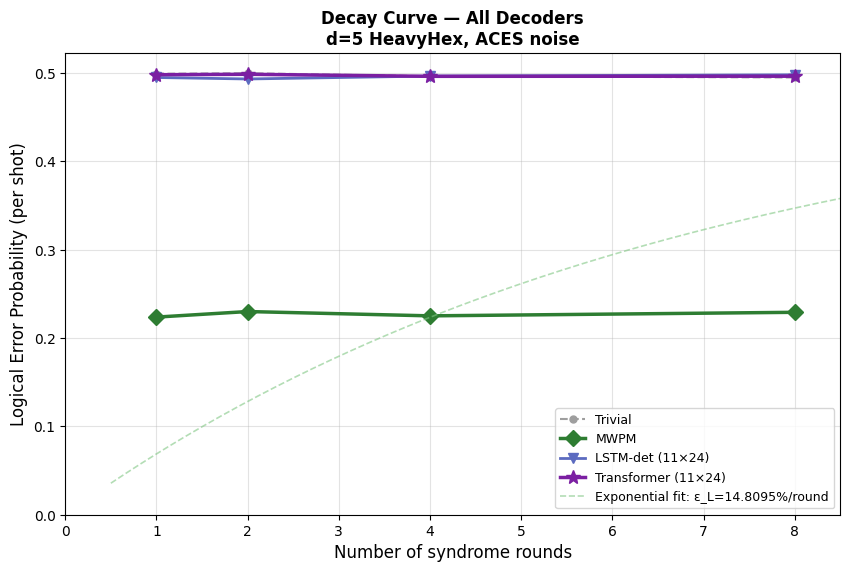

Saved → figures/16_decay_curve_all.png

To extend to r=12,16,20: ask for s_stim_circ_z_r12/16/20.pickle
and add them to ROUNDS_TO_DO above.


In [5]:
# Load trained models from notebook 15
class LSTMDecoder(nn.Module):
    def __init__(self, input_size=24, lstm_hidden=64, lstm_layers=2,
                 dense=[96,48,24], dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, lstm_hidden, lstm_layers,
                            batch_first=True,
                            dropout=dropout if lstm_layers>1 else 0.0)
        layers, in_d = [], lstm_hidden
        for h in dense:
            layers += [nn.Linear(in_d,h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d,1))
        self.head = nn.Sequential(*layers)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)

class SyndromeTransformer(nn.Module):
    def __init__(self, input_size=24, num_steps=11, d_model=64, nhead=4,
                 num_layers=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed  = nn.Embedding(num_steps, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model,32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32,1))
    def forward(self, x):
        tok = self.input_proj(x)
        pos = torch.arange(x.shape[1], device=x.device)
        tok = tok + self.pos_embed(pos).unsqueeze(0)
        return self.head(self.transformer(tok).mean(dim=1)).squeeze(-1)

@torch.no_grad()
def predict(model, X, batch_size=2048):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE))) > 0.5).cpu().numpy())
    return np.concatenate(out)

def build_temporal_input_r(det_events):
    """Same temporal builder as notebook 14 — for 9-round 240-detector circuit."""
    N = det_events.shape[0]
    seq = np.zeros((N, 11, 24), dtype=np.float32)
    seq[:, 0, :12] = det_events[:, 0:12]
    seq[:, 1:10, :] = det_events[:, 12:228].reshape(N, 9, 24)
    seq[:, 10, :12] = det_events[:, 228:240]
    return seq

# Load models
lstm_det = LSTMDecoder(24).to(DEVICE)
ck = torch.load("models/heavyhex/lstm_det.pt", map_location='cpu', weights_only=False)
lstm_det.load_state_dict(ck['model_state'])

transformer = SyndromeTransformer(24, 11).to(DEVICE)
ck = torch.load("models/heavyhex/transformer.pt", map_location='cpu', weights_only=False)
transformer.load_state_dict(ck['model_state'])

print("Models loaded.")

# Evaluate NN decoders at each round count
lstm_lers_decay = []
tr_lers_decay   = []

for r in ROUNDS_TO_EVAL:
    det_r = decay_results[r]['det_events']
    obs_r = decay_results[r]['obs_flips']
    seq_r = build_temporal_input_r(det_r)

    pred_l  = predict(lstm_det, seq_r)
    pred_t  = predict(transformer, seq_r)
    lstm_lers_decay.append(float((pred_l != obs_r).mean()))
    tr_lers_decay.append(float((pred_t != obs_r).mean()))

# Final decay curve with all decoders
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(rounds_arr, triv_lers,        'o--', color='#9E9E9E', lw=1.5, ms=5,  label='Trivial')
ax.plot(rounds_arr, mwpm_lers,        'D-',  color='#2E7D32', lw=2.5, ms=8,  label='MWPM')
ax.plot(rounds_arr, lstm_lers_decay,  'v-',  color='#5C6BC0', lw=2,   ms=7,  label='LSTM-det (11×24)')
ax.plot(rounds_arr, tr_lers_decay,    '*-',  color='#7B1FA2', lw=2.5, ms=10, label='Transformer (11×24)')

if eps_L_mwpm is not None:
    r_fine = np.linspace(0.5, max(ROUNDS_TO_EVAL)+0.5, 200)
    ax.plot(r_fine, decay_model(r_fine, eps_L_mwpm), '--',
            color='#81C784', lw=1.2, alpha=0.6,
            label=f'Exponential fit: ε_L={100*eps_L_mwpm:.4f}%/round')

ax.set_xlabel('Number of syndrome rounds', fontsize=12)
ax.set_ylabel('Logical Error Probability (per shot)', fontsize=12)
ax.set_title('Decay Curve — All Decoders\n'
             'd=5 HeavyHex, ACES noise', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.35)
ax.set_xlim(0, max(ROUNDS_TO_EVAL)+0.5)
ax.set_ylim(0)

fig.savefig('figures/16_decay_curve_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/16_decay_curve_all.png")
print()
print("To extend to r=12,16,20: ask for s_stim_circ_z_r12/16/20.pickle")
print("and add them to ROUNDS_TO_DO above.")